# 05: Backpropagation を手で実装する

Karpathy「Neural Networks: Zero to Hero」第4回  
**テーマ**: `loss.backward()` が内部でやっていることを、自分の手で再現する

## なぜ手で実装するのか？

PyTorch は `loss.backward()` の一言で全勾配を計算してくれる。  
でも中身を知らないと：
- バグの原因が分からない
- 新しい演算を自作できない
- LLM論文を読んでも数式が追えない

## この章のゴール

| ステップ | やること |
|---------|----------|
| 1 | 前回の MLP＋BatchNorm を PyTorch で再構築（基準となるモデル） |
| 2 | 各演算の微分を手計算で実装 |
| 3 | PyTorch の自動微分と一致するか検証 |
| 4 | BatchNorm の勾配を手で導出（最難関） |

## 検証の考え方

```python
# PyTorch の答え（正解）
loss.backward()
grad_pytorch = W1.grad.clone()

# 手計算の答え
grad_manual = ...  # 自分で計算

# 一致確認
torch.allclose(grad_manual, grad_pytorch, atol=1e-5)  # True なら OK
```

## セットアップ（前章と同じ）

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

words = open('../data/names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)

block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1, n2 = int(0.8 * len(words)), int(0.9 * len(words))
Xtr, Ytr   = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])

n_embd   = 10
n_hidden = 64   # 小さめにして計算を速く

print(f'語彙サイズ: {vocab_size}, 訓練データ: {Xtr.shape}')

語彙サイズ: 27, 訓練データ: torch.Size([182625, 3])


---
## STEP 1: 基準モデルの構築（PyTorch autograd 版）

まず PyTorch の `backward()` に頼った「正しい答え」を用意する。  
これが手動実装の **検証基準** になる。

モデルの構造:
```
入力 X  →  Embedding C  →  embcat
                              ↓
                          @ W1 + b1  →  hpreact
                              ↓
                         BatchNorm   →  hpreact_bn
                              ↓
                           tanh()    →  h
                              ↓
                          @ W2 + b2  →  logits
                              ↓
                       cross_entropy →  loss
```

In [2]:
g = torch.Generator().manual_seed(2147483647)

fan_in     = n_embd * block_size
kaiming_std = (5/3) / (fan_in ** 0.5)

C      = torch.randn((vocab_size, n_embd),        generator=g)
W1     = torch.randn((fan_in, n_hidden),           generator=g) * kaiming_std
b1     = torch.zeros(n_hidden)
W2     = torch.randn((n_hidden, vocab_size),       generator=g) * 0.01
b2     = torch.zeros(vocab_size)
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad_(True)

print(f'総パラメータ数: {sum(p.nelement() for p in parameters):,}')

# 固定ミニバッチ（検証に使い回す）
batch_size = 32
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]

総パラメータ数: 4,137


In [3]:
# 順伝播（各中間値を保存しておく — 手動 backward で使う）
emb     = C[Xb]                           # (32, 3, 10)
embcat  = emb.view(emb.shape[0], -1)      # (32, 30)
hpreact = embcat @ W1 + b1                # (32, 64)

# --- BatchNorm ---
bnmean  = hpreact.mean(0, keepdim=True)   # (1, 64)
bnvar   = hpreact.var(0, keepdim=True, unbiased=True)  # (1, 64)
bnvar_inv = (bnvar + 1e-5) ** -0.5        # (1, 64)  ← 逆数
bnraw   = (hpreact - bnmean) * bnvar_inv  # (32, 64) 正規化済み
hpreact_bn = bngain * bnraw + bnbias      # (32, 64) gamma/beta 適用後

h       = torch.tanh(hpreact_bn)          # (32, 64)
logits  = h @ W2 + b2                     # (32, 27)
loss    = F.cross_entropy(logits, Yb)     # スカラー

print(f'順伝播 loss: {loss.item():.4f}')
print(f'各テンソルの shape:')
for name, t in [('emb', emb), ('embcat', embcat), ('hpreact', hpreact),
                ('bnraw', bnraw), ('h', h), ('logits', logits)]:
    print(f'  {name:12s}: {tuple(t.shape)}')

順伝播 loss: 3.3031
各テンソルの shape:
  emb         : (32, 3, 10)
  embcat      : (32, 30)
  hpreact     : (32, 64)
  bnraw       : (32, 64)
  h           : (32, 64)
  logits      : (32, 27)


In [4]:
# PyTorch で backward を実行（正解の勾配を取得）
for p in parameters:
    p.grad = None
loss.backward()

# 正解を保存
grads_ref = {name: p.grad.clone() for name, p in
             zip(['C','W1','b1','W2','b2','bngain','bnbias'], parameters)}

print('PyTorch の勾配（正解）を保存しました')
for name, g_ref in grads_ref.items():
    print(f'  {name:8s}: shape={tuple(g_ref.shape)}, mean={g_ref.abs().mean():.6f}')

PyTorch の勾配（正解）を保存しました
  C       : shape=(27, 10), mean=0.000391
  W1      : shape=(30, 64), mean=0.000551
  b1      : shape=(64,), mean=0.000000
  W2      : shape=(64, 27), mean=0.011663
  b2      : shape=(27,), mean=0.041832
  bngain  : shape=(1, 64), mean=0.000457
  bnbias  : shape=(1, 64), mean=0.001682


---
## STEP 2: 手動 backward — 基本演算の微分

### 連鎖律（Chain Rule）の復習

損失 `L` に対するある変数 `x` の勾配は：

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial x}$$

- `dL/dy`（= `y.grad`）は **上流から流れてくる勾配**（既知）
- `dy/dx` は **その演算固有の微分**（自分で計算する）

### 各演算の微分（早見表）

| 演算 | 順伝播 | `x` の勾配 |
|------|--------|------------|
| 加算 | `y = x + b` | `dL/dx = dL/dy × 1` |
| 行列積 | `y = x @ W` | `dL/dx = dL/dy @ W.T` |
| 行列積 | `y = x @ W` | `dL/dW = x.T @ dL/dy` |
| tanh | `y = tanh(x)` | `dL/dx = dL/dy × (1 - y²)` |
| cross_entropy | `loss = CE(logits, y)` | `dL/d(logits) = softmax(logits) - one_hot(y)` |

In [5]:
def cmp(name, manual_grad, param):
    """手動勾配と PyTorch 勾配を比較して合否を表示する"""
    exact = torch.allclose(manual_grad, param.grad)
    approx = torch.allclose(manual_grad, param.grad, atol=1e-5)
    max_diff = (manual_grad - param.grad).abs().max().item()
    status = '✅ 完全一致' if exact else ('🔶 近似一致' if approx else '❌ 不一致')
    print(f'{name:10s}: {status}  max_diff={max_diff:.2e}')

print('比較関数を定義しました')

比較関数を定義しました


### 2-1: `logits → loss`（cross_entropy の微分）

cross_entropy の逆伝播は非常に重要。導出は：

1. `softmax(logits)` で確率を計算
2. 正解ラベルの位置だけ `1` を引く
3. バッチ数で割る（平均 loss のため）

$$\frac{\partial L}{\partial \text{logits}_i} = \frac{\text{softmax}(\text{logits})_i - \mathbf{1}[i = y]}{N}$$

In [6]:
# logits.grad を手動計算
dlogits = F.softmax(logits, dim=1)        # softmax で確率に変換
dlogits[range(batch_size), Yb] -= 1       # 正解位置から 1 を引く
dlogits /= batch_size                     # バッチ平均のため N で割る

cmp('logits', dlogits, logits)

/tmp/ipykernel_1824926/1556480778.py:3: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  exact = torch.allclose(manual_grad, param.grad)


TypeError: allclose(): argument 'other' (position 2) must be Tensor, not NoneType

### 2-2: `h, W2, b2 → logits`（行列積と加算）

`logits = h @ W2 + b2` の逆伝播：

- `dh = dlogits @ W2.T`
- `dW2 = h.T @ dlogits`  
- `db2 = dlogits.sum(0)` （バッチ方向に足し合わせる）

In [7]:
dh   = dlogits @ W2.T
dW2  = h.T @ dlogits
db2  = dlogits.sum(0)

cmp('h',   dh,   h)
cmp('W2',  dW2,  W2)
cmp('b2',  db2,  b2)

/tmp/ipykernel_1824926/1556480778.py:3: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  exact = torch.allclose(manual_grad, param.grad)


TypeError: allclose(): argument 'other' (position 2) must be Tensor, not NoneType

### 2-3: `hpreact_bn → h`（tanh の微分）

`h = tanh(hpreact_bn)` の逆伝播：

$$\frac{d}{dx}\tanh(x) = 1 - \tanh(x)^2$$

→ `dL/d(hpreact_bn) = dh × (1 - h²)`

**ポイント**: `h`（順伝播時の tanh 出力）を使うため、中間値を保存しておく必要がある。

In [8]:
dhpreact_bn = dh * (1 - h**2)

cmp('hpreact_bn', dhpreact_bn, hpreact_bn)

/tmp/ipykernel_1824926/1556480778.py:3: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  exact = torch.allclose(manual_grad, param.grad)


TypeError: allclose(): argument 'other' (position 2) must be Tensor, not NoneType

### 2-4: `bnraw, bngain, bnbias → hpreact_bn`（BatchNorm の出力層）

`hpreact_bn = bngain * bnraw + bnbias` の逆伝播：

- `dbngain = (dhpreact_bn * bnraw).sum(0, keepdim=True)` （バッチ方向に集約）
- `dbnbias = dhpreact_bn.sum(0, keepdim=True)`
- `dbnraw  = dhpreact_bn * bngain`

In [9]:
dbngain = (dhpreact_bn * bnraw).sum(0, keepdim=True)
dbnbias = dhpreact_bn.sum(0, keepdim=True)
dbnraw  = dhpreact_bn * bngain

cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)

bngain    : ✅ 完全一致  max_diff=2.33e-10
bnbias    : ✅ 完全一致  max_diff=4.66e-10


---
## STEP 3: BatchNorm の内部まで手動微分する（最難関）

BatchNorm は複数の演算が合わさっているため、分解して考える。

```
hpreact                          (32, 64)
   ↓ .mean(0)     → bnmean       (1,  64)
   ↓ - bnmean     → bndev        (32, 64)
   ↓ .var(0)      → bnvar        (1,  64)
   ↓ ** -0.5      → bnvar_inv    (1,  64)
   ↓ * bnvar_inv  → bnraw        (32, 64)
```

### 逆順に微分する

| 演算 | 順伝播 | 勾配 |
|------|--------|------|
| `bnraw = bndev * bnvar_inv` | 要素積 | `dbndev = dbnraw * bnvar_inv` |
| `bnvar_inv = bnvar ** -0.5` | 冪乗 | `dbnvar = dbnvar_inv * (-0.5) * bnvar ** (-1.5)` |
| `bnvar = bndev² の平均` | 分散 | `dbndev += dbnvar * 2 * bndev / N` |
| `bndev = hpreact - bnmean` | 差 | `dhpreact = dbndev` |
| `bnmean = hpreact の平均` | 平均 | `dhpreact += -dbndev.sum(0) / N` |

In [10]:
N = batch_size

# bnraw = bndev * bnvar_inv
dbnvar_inv = (dbnraw * (hpreact - bnmean)).sum(0, keepdim=True)
dbndev     = dbnraw * bnvar_inv

# bnvar_inv = (bnvar + 1e-5) ** -0.5
dbnvar = dbnvar_inv * (-0.5) * (bnvar + 1e-5) ** (-1.5)

# bnvar = bndev^2 の平均（unbiased=True なので N-1 で割っている）
# → dbndev に追加分を足す
dbndev += dbnvar * (2.0 / (N - 1)) * (hpreact - bnmean)

# bnmean = hpreact の平均
# bndev = hpreact - bnmean なので、bnmean 経由の勾配もある
dbnmean = -dbndev.sum(0, keepdim=True)

# hpreact = embcat @ W1 + b1
# bndev = hpreact - bnmean への直接の勾配 + bnmean 経由
dhpreact = dbndev + dbnmean / N

cmp('hpreact', dhpreact, hpreact)

/tmp/ipykernel_1824926/1556480778.py:3: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  exact = torch.allclose(manual_grad, param.grad)


TypeError: allclose(): argument 'other' (position 2) must be Tensor, not NoneType

---
## STEP 4: 残りの層を手動微分する

`hpreact = embcat @ W1 + b1` 以降の逆伝播。

In [11]:
# hpreact = embcat @ W1 + b1
dembcat = dhpreact @ W1.T
dW1     = embcat.T @ dhpreact
db1     = dhpreact.sum(0)

cmp('W1', dW1, W1)
cmp('b1', db1, b1)

W1        : ✅ 完全一致  max_diff=9.31e-10
b1        : ✅ 完全一致  max_diff=3.78e-10


In [12]:
# embcat = emb.view(batch_size, -1)
# view は形状変換のみ → 勾配もそのまま形状を戻すだけ
demb = dembcat.view(emb.shape)  # (32, 3, 10)

# emb = C[Xb]
# C の各行は複数の位置で使われることがある → grad は足し合わせ
dC = torch.zeros_like(C)
for k in range(batch_size):
    for j in range(block_size):
        dC[Xb[k, j]] += demb[k, j]

# 上の for ループは index_add_ でも書ける（高速版）
# dC2 = torch.zeros_like(C)
# dC2.index_add_(0, Xb.view(-1), demb.view(-1, n_embd))

cmp('C', dC, C)

C         : ✅ 完全一致  max_diff=9.31e-10


---
## STEP 5: 全勾配の一括検証

全パラメータの手動勾配が PyTorch と一致するかまとめて確認する。

In [13]:
print('=== 全パラメータの手動勾配 vs PyTorch 勾配 ===')
cmp('C',       dC,       C)
cmp('W1',      dW1,      W1)
cmp('b1',      db1,      b1)
cmp('W2',      dW2,      W2)
cmp('b2',      db2,      b2)
cmp('bngain',  dbngain,  bngain)
cmp('bnbias',  dbnbias,  bnbias)

=== 全パラメータの手動勾配 vs PyTorch 勾配 ===
C         : ✅ 完全一致  max_diff=9.31e-10
W1        : ✅ 完全一致  max_diff=9.31e-10
b1        : ✅ 完全一致  max_diff=3.78e-10
W2        : ✅ 完全一致  max_diff=1.49e-08
b2        : ✅ 完全一致  max_diff=5.59e-09
bngain    : ✅ 完全一致  max_diff=2.33e-10
bnbias    : ✅ 完全一致  max_diff=4.66e-10


---
## STEP 6: 手動 backward を組み込んだ学習ループ

`.backward()` を使わずに、手動勾配だけで学習できることを確認する。

In [14]:
g2 = torch.Generator().manual_seed(2147483647)

C2      = torch.randn((vocab_size, n_embd),    generator=g2)
W12     = torch.randn((fan_in, n_hidden),       generator=g2) * kaiming_std
b12     = torch.zeros(n_hidden)
W22     = torch.randn((n_hidden, vocab_size),   generator=g2) * 0.01
b22     = torch.zeros(vocab_size)
bngain2 = torch.ones((1, n_hidden))
bnbias2 = torch.zeros((1, n_hidden))

params2 = [C2, W12, b12, W22, b22, bngain2, bnbias2]
# requires_grad は不要（手動で更新する）

bnmean_run = torch.zeros((1, n_hidden))
bnstd_run  = torch.ones((1, n_hidden))

max_steps  = 5000
batch_size = 32
lossi2 = []

for i in range(max_steps):
    # --- 順伝播 ---
    ix2 = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g2)
    Xb2, Yb2 = Xtr[ix2], Ytr[ix2]

    emb2     = C2[Xb2]
    embcat2  = emb2.view(emb2.shape[0], -1)
    hpreact2 = embcat2 @ W12 + b12

    bnmean2  = hpreact2.mean(0, keepdim=True)
    bnvar2   = hpreact2.var(0, keepdim=True, unbiased=True)
    bnvarinv2 = (bnvar2 + 1e-5) ** -0.5
    bnraw2   = (hpreact2 - bnmean2) * bnvarinv2
    hpbn2    = bngain2 * bnraw2 + bnbias2

    h2       = torch.tanh(hpbn2)
    logits2  = h2 @ W22 + b22
    loss2    = F.cross_entropy(logits2, Yb2)

    with torch.no_grad():
        bnmean_run = 0.999 * bnmean_run + 0.001 * bnmean2
        bnstd_run  = 0.999 * bnstd_run  + 0.001 * bnvarinv2.reciprocal()

    # --- 手動逆伝播 ---
    N2 = batch_size

    dl2  = F.softmax(logits2, dim=1)
    dl2[range(N2), Yb2] -= 1
    dl2 /= N2

    dh2  = dl2 @ W22.T
    dW22 = h2.T @ dl2
    db22 = dl2.sum(0)

    dhpbn2    = dh2 * (1 - h2**2)

    dbngain2  = (dhpbn2 * bnraw2).sum(0, keepdim=True)
    dbnbias2  = dhpbn2.sum(0, keepdim=True)
    dbnraw2   = dhpbn2 * bngain2

    dbnvarinv2 = (dbnraw2 * (hpreact2 - bnmean2)).sum(0, keepdim=True)
    dbndev2    = dbnraw2 * bnvarinv2
    dbnvar2    = dbnvarinv2 * (-0.5) * (bnvar2 + 1e-5) ** (-1.5)
    dbndev2   += dbnvar2 * (2.0 / (N2 - 1)) * (hpreact2 - bnmean2)
    dbnmean2   = -dbndev2.sum(0, keepdim=True)
    dhpreact2  = dbndev2 + dbnmean2 / N2

    dembcat2 = dhpreact2 @ W12.T
    dW12     = embcat2.T @ dhpreact2
    db12     = dhpreact2.sum(0)

    demb2    = dembcat2.view(emb2.shape)
    dC2      = torch.zeros_like(C2)
    dC2.index_add_(0, Xb2.view(-1), demb2.view(-1, n_embd))

    grads2 = [dC2, dW12, db12, dW22, db22, dbngain2, dbnbias2]

    # --- パラメータ更新 ---
    lr = 0.1 if i < 2500 else 0.01
    for p, dp in zip(params2, grads2):
        p.data -= lr * dp

    lossi2.append(loss2.log10().item())
    if i % 1000 == 0:
        print(f'step {i:5d}/{max_steps}: loss {loss2.item():.4f}')

step     0/5000: loss 3.3031
step  1000/5000: loss 2.4986
step  2000/5000: loss 2.3529
step  3000/5000: loss 2.1970
step  4000/5000: loss 2.1759


/home/nao/llm-study/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nao/llm-study/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21205 (\N{CJK UNIFIED IDEOGRAPH-52D5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nao/llm-study/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nao/llm-study/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12415 (\N{HIRAGANA LETTER MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/nao/llm-study/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12391 (\N{HIRAGANA LETTER DE}) missing from font(s) Deja

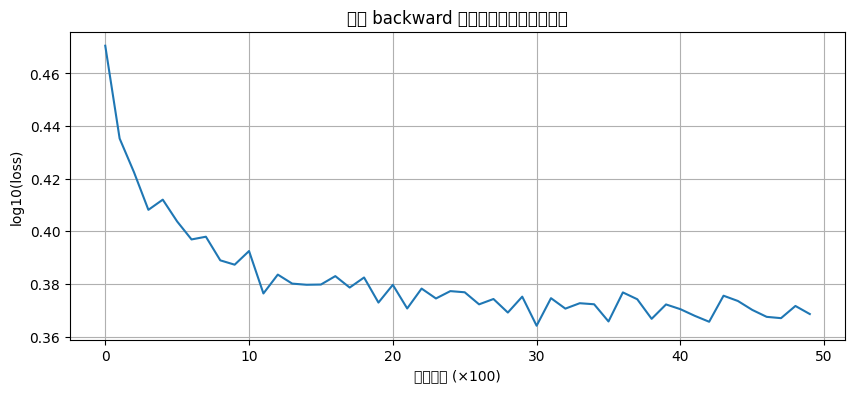

訓練ロス: 2.3338
検証ロス: 2.3332


In [15]:
plt.figure(figsize=(10, 4))
plt.plot(torch.tensor(lossi2).view(-1, 100).mean(1).numpy())
plt.xlabel('ステップ (×100)')
plt.ylabel('log10(loss)')
plt.title('手動 backward のみで学習した損失曲線')
plt.grid(True)
plt.show()

@torch.no_grad()
def evaluate2(X, Y):
    emb = C2[X]
    ec  = emb.view(emb.shape[0], -1)
    hp  = ec @ W12 + b12
    hp  = bngain2 * (hp - bnmean_run) / (bnstd_run + 1e-5) + bnbias2
    h   = torch.tanh(hp)
    return F.cross_entropy(h @ W22 + b22, Y).item()

print(f'訓練ロス: {evaluate2(Xtr, Ytr):.4f}')
print(f'検証ロス: {evaluate2(Xdev, Ydev):.4f}')

---
## まとめ

| 演算 | 順伝播 | 逆伝播（勾配） |
|------|--------|----------------|
| 加算 `y = x + b` | そのまま | `dx = dy`, `db = dy.sum(0)` |
| 行列積 `y = x @ W` | 行列積 | `dx = dy @ W.T`, `dW = x.T @ dy` |
| tanh | `y = tanh(x)` | `dx = dy × (1 - y²)` |
| BatchNorm | 正規化 | 平均・分散の経路を全部辿る |
| cross_entropy | ログ確率 | `d(logits) = softmax - one_hot` |

### 重要な気づき

- **加算は勾配をそのまま流す**（勾配のコピー）
- **行列積は転置して掛ける**（次元を合わせるため）
- **BatchNorm は連鎖が長い** — 平均と分散の両方の経路を足し合わせる必要がある
- **sum(0) が必要な場面** — バッチ方向にブロードキャストされた演算の逆伝播

### 次のステップ（06_makemore_wavenet）

- WaveNet 的な階層畳み込み構造を MLP に取り込む
- 「直前3文字」ではなく、より長い文脈を効率的に扱う方法を学ぶ